In [1]:
import os
import re
import pickle
import subprocess
import pandas as pd
from glob import glob
import numpy as np
from scipy.stats import mannwhitneyu
import scipy
from scipy.stats import spearmanr, pearsonr
import qtl.plot
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import copy
from tqdm import tqdm
plt.rcParams.update({'font.family':'Helvetica', 
                     'svg.fonttype':'none',
                     'pdf.fonttype':42, 
                     'font.size':12})


def parse_variant_id(row, col=1):
    eles = row[col].split(':')
    return f"chr{eles[0]}", eles[1], eles[2], eles[3]


def is_snp(row):
    return (len(row['REF']) == 1) &  (len(row['ALT']) == 1)


def caqtl_variant_id_chrombpnet_input(row):
    return pd.Series({"CHR": row['chrom'], 
            "POS0": int(row['pos']) - 1, # the variant position is 1-based, change to 0-based
            "REF": row[4],
            "ALT": row[5],
            "variant_id": row[1],
            "is_snp": (len(row['ref']) == 1) &  (len(row['alt']) == 1),
            "alt_not_A1": row['alt'] != row[4]})


def to_chrombpnet_input(df):
    return df.apply(caqtl_variant_id_chrombpnet_input, axis=1)
    

def split_dataframe(df, chunk_size):
    num_chunks = (len(df) + chunk_size - 1) // chunk_size  # Calculate number of chunks
    chunks = []
    for i in range(num_chunks):
        start_index = i * chunk_size
        end_index = min((i + 1) * chunk_size, len(df))
        chunks.append(df.iloc[start_index:end_index])
    return chunks


def peak_dist_to_variant(row, 
                         peak_col='phenotype_id', 
                         variant_col='variant_id'):
    region = row[peak_col]
    region_start, region_end = region.split(":")[1].split("-")
    region_start = int(region_start)
    region_end = int(region_end)
    snp_pos = int(row[variant_col].split(":")[1])

    if snp_pos < region_start:
        dist = (region_start - snp_pos)
    elif snp_pos > region_end:
        dist = (snp_pos - region_end)
    else:
        dist = 0
    return dist



def scatter(x, y, c=None, kind='scatter', cmap=None, colorbar=True, corr_loc='lower right', show_pval=False,
            lowess=False, lowess_frac=0.3, gridsize=50, extent=None, xscale='linear', yscale='linear', margins=0,
            clip_on=False, entity='Cells', ax=None, cax=None, dr=1, **kwargs):
    """Wrapper for scatter plot, with option to plot density"""

    if kind == 'scatter':
        if ax is None:
            ax = qtl.plot.setup_figure(2,2)
            ax.margins(margins)
            qtl.plot.format_plot(ax, x_offset=6, y_offset=6)
        if 'ec' not in kwargs:
            kwargs.update({'ec':'none'})
        ax.set_xscale(xscale)
        ax.set_yscale(yscale)
        ax.scatter(x, y, c=c, clip_on=clip_on, **kwargs)

    elif kind == 'density':
        if ax is None:
            if colorbar:
                xspace = [0.75, dr]
            else:
                xspace = [0.75, 0.25]
            ax, cax = qtl.plot.setup_figure(2, 2, xspace=xspace, colorbar=colorbar)
            ax.margins(margins)
            qtl.plot.format_plot(ax, x_offset=6, y_offset=6)
        if cmap is None:
            cmap = copy.copy(plt.cm.RdYlBu_r)
            cmap.set_bad('w', 1.)

        h = ax.hexbin(x, y, gridsize=gridsize, extent=extent, bins='log', mincnt=1, linewidths=0.1,
                      xscale=xscale, yscale=yscale, cmap=cmap, clip_on=clip_on, **kwargs)
        if colorbar and cax is not None:
            bbox = cax.get_window_extent()
            if bbox.height >= bbox.width:
                plt.colorbar(h, cax=cax, ticks=ticker.LogLocator(numticks=5))
                cax.set_ylabel('log$\mathregular{_{10}}$('+entity+')', fontsize=11)
            else:
                plt.colorbar(h, cax=cax, ticks=ticker.LogLocator(numticks=5), orientation='horizontal')
                cax.xaxis.set_label_position('top')
                # cax.xaxis.tick_top()
                cax.set_xlabel('log$\mathregular{_{10}}$('+entity+')', fontsize=11)

    if lowess:
        lw = sm.nonparametric.lowess(y, x, lowess_frac)
        ax.plot(lw[:, 0], lw[:, 1], '-', color='tab:red', lw=2)

    if corr_loc is not None:
        rho, pval = scipy.stats.spearmanr(x, y, nan_policy='omit')
        r, pval = scipy.stats.pearsonr(x, y) 
        t = fr"$\rho$ = {rho:.2f}"+ f"\nR = {r:.2f}"
        if show_pval:
            t += f"\nP = {pval:.2g}"
        if corr_loc == 'lower right':
            ax.text(1, 0, t, fontsize=11, ha='right', va='bottom', transform=ax.transAxes)
        elif corr_loc == 'upper right':
            ax.text(1, 0.98, t, fontsize=11, ha='right', va='top', transform=ax.transAxes)
        elif corr_loc == 'upper left':
            ax.text(0.02, 0.98, t, fontsize=11, ha='left', va='top', transform=ax.transAxes)
        elif corr_loc == 'lower left':
            ax.text(0.02, 0, t, fontsize=11, ha='left', va='bottom', transform=ax.transAxes)

    if isinstance(x, pd.Series):
        ax.set_xlabel(x.name, fontsize=12)
    if isinstance(y, pd.Series):
        ax.set_ylabel(y.name, fontsize=12)

    if kind == 'density' and colorbar:
        return ax, cax, h
    else:
        return ax

<>:110: SyntaxWarning: invalid escape sequence '\m'
<>:115: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarning: invalid escape sequence '\m'
<>:115: SyntaxWarning: invalid escape sequence '\m'
/scratch/230903.1.whole/ipykernel_18635/469527452.py:110: SyntaxWarning: invalid escape sequence '\m'
  cax.set_ylabel('log$\mathregular{_{10}}$('+entity+')', fontsize=11)
/scratch/230903.1.whole/ipykernel_18635/469527452.py:115: SyntaxWarning: invalid escape sequence '\m'
  cax.set_xlabel('log$\mathregular{_{10}}$('+entity+')', fontsize=11)


# General input and output data

In [2]:
# raw data from TenK10K
top_caqtl_fn = "/illumina/scratch/deep_learning/lchen4/tenk10k/data/caQTL/TenK10K.caQTL.1Mb.final_summary_qval005_feb02_2026_freeze.csv"
finemapped_caqtl_fn = "/illumina/scratch/deep_learning/lchen4/tenk10k/data/caQTL/FineMapping/SuSiEResults_new/all_celltypes_caQTL_susie_annotated/*csv"

# derived data Ling Chen generated
cell_type_counts_fn = "data/combined_obs_cell_type_counts.tsv"
score_fn = 'data/common_snp_scores_all_contexts.parquet'

# too few data points for accurate spearmanr/pearsonr estimation
exclude_celltypes = ['CD4_Proliferating', 
                     'ILC', 
                     'CD8_Proliferating']

In [3]:
out_figure_dir = 'figures/'
if not os.path.exists(out_figure_dir): os.makedirs(out_figure_dir)

In [4]:
# load data
cell_type_counts = pd.read_csv(cell_type_counts_fn, sep='\t')
cell_type_counts['label'] = cell_type_counts['predicted.id'] + ' (N=' + cell_type_counts['count'].astype(str) + ')'
cell_type_counts = cell_type_counts.set_index("predicted.id")
cell_type_counts

,count,label
predicted.id,,
CD14_Mono,767874,CD14_Mono (N=767874)
CD4_TCM,543523,CD4_TCM (N=543523)
CD4_Naive,457715,CD4_Naive (N=457715)
NK,432705,NK (N=432705)
CD8_TEM,357483,CD8_TEM (N=357483)
CD16_Mono,180128,CD16_Mono (N=180128)
B_naive,152441,B_naive (N=152441)
B_intermediate,114963,B_intermediate (N=114963)
CD4_CTL,105062,CD4_CTL (N=105062)


# Join chromBPNet scores with caQTL scores

In [6]:
# load chrombpnet score
score = pd.read_parquet(score_fn)
score.shape

(242748688, 8)

In [7]:
score.head(2)

,CHR,POS0,REF,ALT,log_counts_diff,log_probs_diff_abs_sum,probs_jsd_diff,celltype
0,chr1,10326,T,C,0.006008,8.093608,0.001857,ASDC
1,chr1,10491,C,T,-0.024017,-38.831269,-0.014520,ASDC


## Top variants

In [ ]:
# load caqtl effects
df_top = pd.read_csv(top_caqtl_fn, index_col=0)
df_top = df_top.rename(columns={'cell_types': 'celltype'})
df_top['dist_to_variant'] = df_top.apply(peak_dist_to_variant, args=('phenotype_id', 'variant_id'), axis=1)

In [9]:
df_top[['CHR', 'POS', 'REF', 'ALT']] = df_top.apply(parse_variant_id, axis=1, args=('variant_id', ), result_type='expand')
df_top['POS0'] = df_top['POS'].astype(int) - 1
df_top['is_snp'] = df_top.apply(is_snp, axis=1)

In [10]:
df_top['is_snp'].value_counts()

is_snp
True     186489
False     56736
Name: count, dtype: int64

In [11]:
df_top = df_top[df_top['is_snp']]
df_top = df_top.merge(score, on=['CHR', 'POS0', 'REF', 'ALT', 'celltype'], how='left')

In [12]:
df_top.head(2)

,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,ma_samples,...,dist_to_variant,CHR,POS,REF,ALT,POS0,is_snp,log_counts_diff,log_probs_diff_abs_sum,probs_jsd_diff
0,chr3:14216099-14217148,6086,0.979188,303.42523,341.29126,5.810798e-09,3:14227894:C:T,11270,11270,207,...,10746,chr3,14227894,C,T,14227893,True,-0.020170,-23.488764,-0.011188
1,chr3:35745442-35746758,5823,0.982035,215.25832,339.34607,4.880434e-08,3:35745969:A:C,-132,-132,264,...,0,chr3,35745969,A,C,35745968,True,-0.026888,-26.774405,-0.012051


In [14]:
df_top[df_top['log_counts_diff'].isnull()].shape

(0, 30)

In [15]:
outfn = os.path.join('data/', os.path.basename(top_caqtl_fn).split('.csv')[0] + '_w_ChromBPNetScores.parquet')
print(outfn)
df_top.to_parquet(outfn)

data/TenK10K.caQTL.1Mb.final_summary_qval005_feb02_2026_freeze_w_ChromBPNetScores.parquet


In [5]:
# df_top = pd.read_parquet('data/TenK10K.caQTL.1Mb.final_summary_qval005_feb02_2026_freeze_w_ChromBPNetScores.parquet')

## Finemapped variants

In [17]:
fns = glob(finemapped_caqtl_fn)
df_fm = []
for fn in tqdm(fns):
    cell_type = os.path.basename(fn).split('_susie_annotated.csv')[0]
    t = pd.read_csv(fn)
    t['celltype'] = cell_type
    df_fm.append(t)
df_fm = pd.concat(df_fm)
df_fm[['CHR', 'POS', 'REF', 'ALT']] = df_fm.apply(parse_variant_id, axis=1, args=('SNP', ), result_type='expand')
df_fm['POS0'] = df_fm['POS'].astype(int) - 1
df_fm['is_snp'] = df_fm.apply(is_snp, axis=1)
df_fm['dist_to_variant'] = df_fm.apply(peak_dist_to_variant, args=('peak', 'SNP'), axis=1)
df_fm = df_fm[df_fm['is_snp']]
df_fm = df_fm.merge(score, on=['CHR', 'POS0', 'REF', 'ALT', 'celltype'], how='left')

100%|██████████| 26/26 [00:10<00:00,  2.49it/s]


In [18]:
print(df_fm[df_fm['log_counts_diff'].isnull()].shape)
print(df_fm.shape)
df_fm.head(2)

(0, 18)
(8309958, 18)


,celltype,peak,SNP,PIP,Credible_Set,slope,af,pval_nominal,CHR,POS,REF,ALT,POS0,is_snp,dist_to_variant,log_counts_diff,log_probs_diff_abs_sum,probs_jsd_diff
0,CD4_Naive,chr1:100075078-100075342,1:100781717:T:G,0.005011,1,0.323939,0.103692,0.000053,chr1,100781717,T,G,100781716,True,706375,-0.123369,-92.179415,-0.042363
1,CD4_Naive,chr1:100075078-100075342,1:100785357:C:A,0.005011,1,0.323939,0.103692,0.000053,chr1,100785357,C,A,100785356,True,710015,-0.002139,-11.136982,-0.003987


In [136]:
outfn = 'data/TenK10K.caQTL.Final1Mb.susie_finemapped_results_w_ChromBPNetScores.parquet'
print(outfn)
df_fm.to_parquet(outfn)

data/TenK10K.caQTL.Final1Mb.susie_finemapped_results_w_ChromBPNetScores.parquet


In [6]:
# df_fm = pd.read_parquet('data/TenK10K.caQTL.Final1Mb.susie_finemapped_results_w_ChromBPNetScores.parquet')

# ChromBPNet score vs. observed caQTL effects

## Finemapped variants

### Observed effect size vs. ChromBPNet score, straitified by distance

In [7]:
df_fm.head(2)

,celltype,peak,SNP,PIP,Credible_Set,slope,af,pval_nominal,CHR,POS,REF,ALT,POS0,is_snp,dist_to_variant,log_counts_diff,log_probs_diff_abs_sum,probs_jsd_diff
0,CD4_Naive,chr1:100075078-100075342,1:100781717:T:G,0.005011,1,0.323939,0.103692,0.000053,chr1,100781717,T,G,100781716,True,706375,-0.123369,-92.179415,-0.042363
1,CD4_Naive,chr1:100075078-100075342,1:100785357:C:A,0.005011,1,0.323939,0.103692,0.000053,chr1,100785357,C,A,100785356,True,710015,-0.002139,-11.136982,-0.003987


In [8]:
records = []
for d in [0, 500, 1000, 5000, 10_000, 100_000, 1000000]:
    for cell_type, grp in df_fm.groupby('celltype'):
        for min_pip in [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
            t = grp[(grp['dist_to_variant'] <= d) & (grp['PIP'] >= min_pip)]
            if len(t) > 2:
                for col1 in ['slope']:
                    for col2 in ['log_counts_diff']: 
                        record = {
                            "metric1": col1,
                            "metric2": col2,
                            "spearmanr": spearmanr(t[col1], t[col2])[0],
                            "pearsonr": pearsonr(t[col1], t[col2])[0],
                            "N": len(t),
                            "max_dist_to_variant": d,
                            "cell type": cell_type,
                            'min_pip': min_pip
                        }
                        records.append(record)
perf = pd.DataFrame(records).sort_values("spearmanr", ascending=False)
perf['cell type count'] = perf.apply(lambda x: cell_type_counts.loc[x['cell type'], 'count'], axis=1)
perf['label'] = perf['cell type'] + ' (#cells=' + perf['cell type count'].astype(str) + ')'
perf.to_csv(os.path.join('data/caQTL_slop_vs_ChromBPNet_scores_finemapped_variants.csv'), index=False)

Plotting 25 cell types


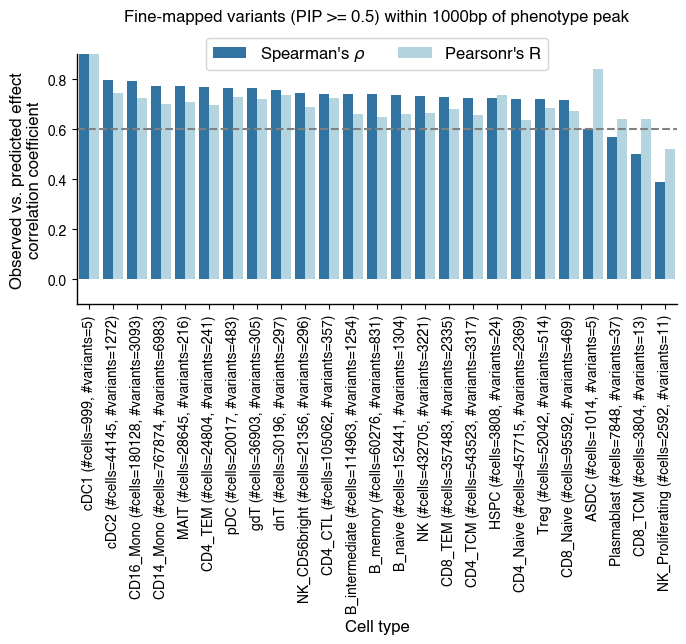

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


In [9]:
#for max_dist in [0,1000, 5000]:
for max_dist in [1000]:
    t = perf[(perf['metric1'] == 'slope') \
            & (perf['metric2'] == 'log_counts_diff') \
            & (perf['max_dist_to_variant'] == max_dist)\
            & (perf['min_pip'] == 0.5)]
    # val_cell_types = cell_type_counts[cell_type_counts.index.isin(t['cell type'].unique())].index
    # t = t.set_index('cell type').loc[val_cell_types].reset_index()
    t = t[~t['cell type'].isin(exclude_celltypes)]
    print(f"Plotting {t['cell type'].nunique()} cell types")
    t = t.rename(columns={'spearmanr': 'corr_spearmanr', 'pearsonr': 'corr_pearsonr', 'predicted.id': 'cell type'})
    t = pd.wide_to_long(t, stubnames=['corr'],  
                    i=['metric1', 'metric2', 'N',
                       'max_dist_to_variant', 
                       'cell type', 
                       'cell type count',
                       'label'],
                    j='corr_method',
                    sep='_',
                    suffix='.+').reset_index()
    t['label'] = t.apply(lambda x: x['label'].replace(')', f", #variants={x['N']})"),axis=1)

    ax = qtl.plot.setup_figure(6, 2.5)
    qtl.plot.format_plot(ax)
    # sns.barplot(x='label', y=metric, 
    #                data=t, color='grey')
    sns.barplot(x='label', y='corr',  hue='corr_method',
                data=t, 
                palette=['tab:blue', 'lightblue'])
    ax.set_xlabel('Cell type')
    ax.set_ylabel('Observed vs. predicted effect\ncorrelation coefficient')
    #ax.bar_label(ax.containers[0], fmt='%.1f', padding=0, fontsize=8)
    #ax.bar_label(ax.containers[1], fmt='%.1f', padding=0, fontsize=8)
    if max_dist == 0:
        ax.set_title('Fine-mapped variants (PIP >= 0.5) within phenotype peak',fontsize=12, y=1.1)
    else:
        ax.set_title(f'Fine-mapped variants (PIP >= 0.5) within {max_dist}bp of phenotype peak',fontsize=12, y=1.1)
    handles, labels = plt.gca().get_legend_handles_labels()
    ax.legend(handles, ["Spearman's " + r"$\rho$", "Pearsonr's R"], 
              loc='upper center', ncols=2, bbox_to_anchor=(0.5, 1.1))
    
    ax.axhline(0.6, ls='--', color='grey')
    
    ax.set_ylim(-0.1, 0.9)
    plt.xticks(rotation=90)
    plt.show()
    
    ax.get_figure().savefig(os.path.join(out_figure_dir, f"TenK10K_chromBPNet_pred_vs_observed_straitified_by_cell_type_max_dist_{max_dist}.pdf"),
                    dpi=300, bbox_inches='tight')

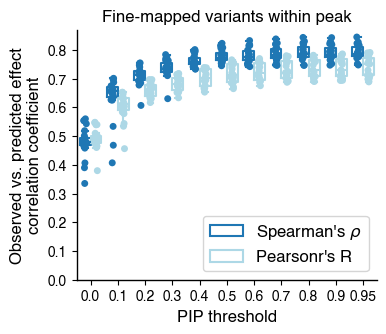

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


In [10]:
t = perf[(perf['metric1'] == 'slope') \
        & (perf['metric2'] == 'log_counts_diff') \
        & (perf['max_dist_to_variant'] == 0) \
        & (perf['N'] >= 50)]
t = t[~t['cell type'].isin(exclude_celltypes)]
t = t.rename(columns={'spearmanr': 'corr_spearmanr', 
                      'pearsonr': 'corr_pearsonr'})
t = pd.wide_to_long(t, stubnames=['corr'],  
                i=['metric1', 'metric2', 'N',
                   'max_dist_to_variant', 
                   'cell type',
                   'cell type count',
                   'label', 'min_pip'],
                j='corr_method',
                sep='_',
                suffix='.+').reset_index()


ax = qtl.plot.setup_figure(3, 2.5)
qtl.plot.format_plot(ax)
sns.boxplot(x='min_pip', y='corr',  hue='corr_method',
            data=t, fill=False, fliersize=0, 
            palette=['tab:blue', 'lightblue'])
sns.stripplot(x='min_pip', y='corr', hue='corr_method', 
               data=t, dodge=True, palette=['tab:blue', 'lightblue'])
ax.set_xlabel('PIP threshold')
ax.set_ylabel('Observed vs. predicted effect\ncorrelation coefficient')
ax.set_title('Fine-mapped variants within peak', fontsize=12)
ax.set_ylim(0)
#ax.set_xticklabels( [0, 500, 1000, 5000, '1e5', '1e6'])

handles, labels = plt.gca().get_legend_handles_labels()
ax.legend(handles[:2], ["Spearman's " + r"$\rho$", "Pearsonr's R"], loc='lower right')
plt.show()

ax.get_figure().savefig(os.path.join(out_figure_dir, f"TenK10K_chromBPNet_pred_vs_observed_scatterplot_variant_within_the_peak.pdf"),
                        dpi=300, bbox_inches='tight')

/scratch/230903.1.whole/ipykernel_18635/1764546225.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels( [0, 500, 1000, 5000, '1e4', '1e5', '1e6'])


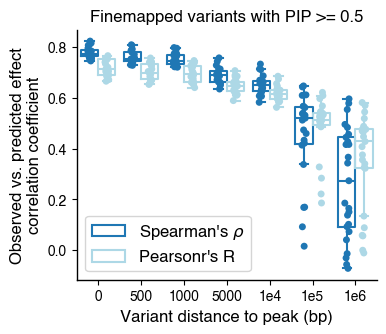

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


In [11]:
#for min_pip in [0, 0.5, 0.6, 0.7, 0.8, 0.9]:
for min_pip in [0.5]:
    t = perf[(perf['metric1'] == 'slope') \
            & (perf['metric2'] == 'log_counts_diff') \
            & (perf['min_pip'] == min_pip) \
            & (perf['N'] >= 50)]
    t = t[~t['cell type'].isin(exclude_celltypes)]
    t = t.rename(columns={'spearmanr': 'corr_spearmanr', 'pearsonr': 'corr_pearsonr'})
    t = pd.wide_to_long(t, stubnames=['corr'],  
                    i=['metric1', 'metric2', 'N',
                       'max_dist_to_variant', 
                       'cell type',
                       'cell type count',
                       'label'],
                    j='corr_method',
                    sep='_',
                    suffix='.+').reset_index()
    
    
    ax = qtl.plot.setup_figure(3, 2.5)
    qtl.plot.format_plot(ax)
    sns.boxplot(x='max_dist_to_variant', y='corr',  hue='corr_method',
                data=t, fill=False, fliersize=0, 
                palette=['tab:blue', 'lightblue'])
    sns.stripplot(x='max_dist_to_variant', y='corr', hue='corr_method', 
                   data=t, dodge=True, palette=['tab:blue', 'lightblue'])
    ax.set_xlabel('Variant distance to peak (bp)')
    ax.set_ylabel('Observed vs. predicted effect\ncorrelation coefficient')
    ax.set_xticklabels( [0, 500, 1000, 5000, '1e4', '1e5', '1e6'])
    ax.set_title(f'Finemapped variants with PIP >= {min_pip:.1f}', fontsize=12)
    handles, labels = plt.gca().get_legend_handles_labels()
    ax.legend(handles[:2], ["Spearman's " + r"$\rho$", "Pearsonr's R"], loc='lower left')
    plt.show()
    
    ax.get_figure().savefig(os.path.join(out_figure_dir, f"TenK10K_chromBPNet_finemapped_SNP_minPIP{min_pip:1f}_pred_vs_observed_straitified_by_variant_distance_to_peak.pdf"),
                            dpi=300, bbox_inches='tight')

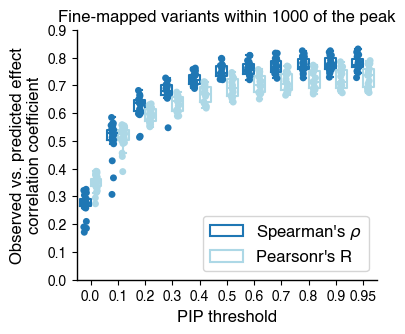

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(29252, 18) (14213,)


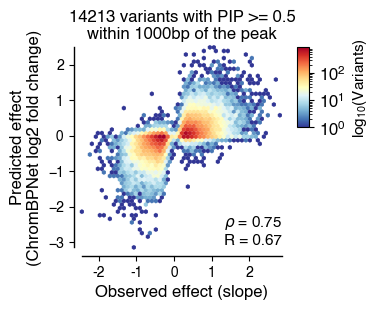

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


In [13]:
for max_dist in [1000]:
    t = perf[(perf['metric1'] == 'slope') \
            & (perf['metric2'] == 'log_counts_diff') \
            & (perf['max_dist_to_variant'] == max_dist) \
            & (perf['N'] >= 50)]
    t = t[~t['cell type'].isin(exclude_celltypes)]
    t = t.rename(columns={'spearmanr': 'corr_spearmanr', 
                          'pearsonr': 'corr_pearsonr'})
    t = pd.wide_to_long(t, stubnames=['corr'],  
                    i=['metric1', 'metric2', 'N',
                       'max_dist_to_variant', 
                       'cell type',
                       'cell type count',
                       'label',
                       'min_pip'],
                    j='corr_method',
                    sep='_',
                    suffix='.+').reset_index()

    ax = qtl.plot.setup_figure(3, 2.5)
    qtl.plot.format_plot(ax)
    sns.boxplot(x='min_pip', y='corr',  hue='corr_method',
                data=t, fill=False, fliersize=0, 
                palette=['tab:blue', 'lightblue'])
    sns.stripplot(x='min_pip', y='corr', hue='corr_method', 
                   data=t, dodge=True, palette=['tab:blue', 'lightblue'])
    ax.set_xlabel('PIP threshold')
    ax.set_ylabel('Observed vs. predicted effect\ncorrelation coefficient')
    ax.set_ylim(0, 0.9)
    if max_dist > 0:
        ax.set_title(f'Fine-mapped variants within {max_dist} of the peak', fontsize=12)
    else:
        ax.set_title(f'Fine-mapped variants within the peak', fontsize=12)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    ax.legend(handles[:2], ["Spearman's " + r"$\rho$", "Pearsonr's R"], loc='lower right')
    plt.show()
    
    ax.get_figure().savefig(os.path.join(out_figure_dir, f"TenK10K_chromBPNet_pred_vs_observed_scatterplot_variant_within_{max_dist}bp_of_the_peak.pdf"),
                            dpi=300, bbox_inches='tight')

    for min_pip in [0.5]:
        t = df_fm[(df_fm['dist_to_variant'] <= max_dist) & (df_fm['PIP'] >= min_pip) & (df_fm['is_snp'])]
        print(t.shape, t['SNP'].unique().shape)
        
        ax, cax, h = scatter(t['slope'], t['log_counts_diff'],
                             kind='density', entity='Variants')
        ax.set_xlabel(f'Observed effect (slope)')
        ax.set_ylabel(f'Predicted effect\n(ChromBPNet log2 fold change)')
        if max_dist > 0:
            ax.set_title(f"{len(t['SNP'].unique())} variants with PIP >= {min_pip:.1f}\nwithin {max_dist:.0f}bp of the peak", fontsize=12)
        else:
            ax.set_title(f"{len(t['SNP'].unique())} variants with PIP >= {min_pip:.1f}\nwithin the peak", fontsize=12)
        ax.set_xticks([-2, -1, 0, 1, 2],[-2, -1, 0, 1, 2])
        plt.show()
        
        ax.get_figure().savefig(os.path.join(out_figure_dir, f"TenK10K_chromBPNet_finemapped_variants_minPIP{min_pip:.1f}_pred_vs_observed_scatterplot_variant_within_{max_dist}bp_of_the_peak.pdf"),
                                dpi=300, bbox_inches='tight')

## Compare top variants and fine-mapped variants results

In [14]:
records = []
for d in [0, 500, 1000, 5000, 100000, 1000000]:
    for cell_type, grp in df_top.groupby('celltype'):
        for min_af in [0]:
            t = grp[(grp['dist_to_variant'] <= d) & (grp['af'] >= min_af)]
            t = t[t['log_counts_diff'].notnull()]
            for col1 in ['slope']:
                for col2 in ['log_counts_diff']:
                    record = {
                        "metric1": col1,
                        "metric2": col2,
                        "spearmanr": spearmanr(t[col1], t[col2])[0],
                        "pearsonr": pearsonr(t[col1], t[col2])[0],
                        "N": len(t),
                        "max_dist_to_variant": d,
                        "cell type": cell_type,
                        "min_af": min_af
                    }
                    records.append(record)
top_df = pd.DataFrame(records).sort_values("spearmanr", ascending=False)
top_df['cell type count'] = top_df.apply(lambda x: cell_type_counts.loc[x['cell type'], 'count'], axis=1)
top_df['label'] = top_df['cell type'] + ' (#cells=' + top_df['cell type count'].astype(str) + ')'

In [15]:
top_df.to_csv('data/caQTL_slop_vs_ChromBPNet_scores_top_variants.csv')

In [16]:
# top_df = pd.read_csv('data/caQTL_slop_vs_ChromBPNet_scores_top_variants.csv')
top_df = top_df[top_df['min_af'] == 0]
top_df.drop('min_af', axis=1, inplace=True)
top_df.head(2)

,metric1,metric2,spearmanr,pearsonr,N,max_dist_to_variant,cell type,cell type count,label
5,slope,log_counts_diff,0.776192,0.709203,5078,0,CD16_Mono,180128,CD16_Mono (#cells=180128)
21,slope,log_counts_diff,0.773118,0.707929,2404,0,cDC2,44145,cDC2 (#cells=44145)


In [17]:
finemapped_df = pd.read_csv('data/caQTL_slop_vs_ChromBPNet_scores_finemapped_variants.csv')

In [18]:
finemapped_df = finemapped_df[finemapped_df['min_pip'] >= 0.5]
finemapped_df.drop('min_pip', axis=1, inplace=True)
finemapped_df.head(2)

,metric1,metric2,spearmanr,pearsonr,N,max_dist_to_variant,cell type,cell type count,label
0,slope,log_counts_diff,1.0,0.996706,4,0,NK_Proliferating,2592,NK_Proliferating (#cells=2592)
1,slope,log_counts_diff,1.0,0.996706,4,0,NK_Proliferating,2592,NK_Proliferating (#cells=2592)


In [19]:
top_df['variant type'] = 'Top variants'
finemapped_df['variant type'] = 'Finemapped'
tperf = pd.concat([top_df, finemapped_df])

/scratch/230903.1.whole/ipykernel_18635/3917256711.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels( [0, 500, 1000, 5000, '1e5', '1e6'])


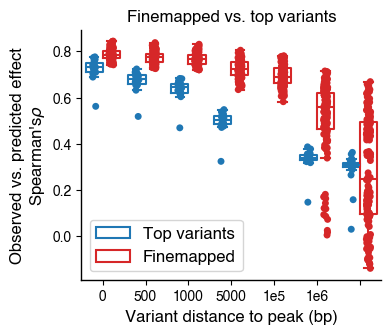

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


In [21]:
t = tperf[(tperf['metric1'] == 'slope') \
        & (tperf['metric2'] == 'log_counts_diff') \
        & (tperf['N'] >= 50)]
t = t[~t['cell type'].isin(exclude_celltypes)]
t = t.rename(columns={'spearmanr': 'corr_spearmanr', 
                      'pearsonr': 'corr_pearsonr'})

ax = qtl.plot.setup_figure(3, 2.5)
qtl.plot.format_plot(ax)
sns.boxplot(x='max_dist_to_variant', y='corr_spearmanr',  hue='variant type',
            data=t, fill=False, fliersize=0, 
            palette=['tab:blue', 'tab:red'])
sns.stripplot(x='max_dist_to_variant', y='corr_spearmanr', hue='variant type', 
               data=t, dodge=True, palette=['tab:blue', 'tab:red'])
ax.set_xlabel('Variant distance to peak (bp)')
ax.set_ylabel("Observed vs. predicted effect\nSpearman's" + r"$\rho$")
ax.set_xticklabels( [0, 500, 1000, 5000, '1e5', '1e6'])
ax.set_title(f'Finemapped vs. top variants', fontsize=12)
handles, labels = plt.gca().get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], loc='lower left')
plt.show()

ax.get_figure().savefig(os.path.join(out_figure_dir, f"TenK10K_chromBPNet_finemapped_vs_top_variants_pred_vs_observed_straitified_by_variant_distance_to_peak.pdf"),
                        dpi=300, bbox_inches='tight')